In [2]:
# 1. Download the dataset directly from GitHub
!git clone https://github.com/laxmimerit/male-female-face-dataset.git

import os
import shutil

# Ensure a clean slate for the target dataset directory before creation
if os.path.exists('/content/Dataset'):
    shutil.rmtree('/content/Dataset')

# 2. Create the target directories expected by the CNN training script
os.makedirs('/content/Dataset/male', exist_ok=True)
os.makedirs('/content/Dataset/female', exist_ok=True)

# 3. Define the paths to the downloaded training images
source_male = '/content/male-female-face-dataset/Training/male'
source_female = '/content/male-female-face-dataset/Training/female'

# 4. Copy the images into your working Dataset folder
if os.path.exists(source_male) and os.path.exists(source_female):
    for img in os.listdir(source_male):
        shutil.copy(os.path.join(source_male, img), '/content/Dataset/male/')

    # FIX: Corrected typo from os.path.isdir to os.listdir
    for img in os.listdir(source_female):
        shutil.copy(os.path.join(source_female, img), '/content/Dataset/female/')

    # Verify that the target directories are indeed populated
    if os.path.exists('/content/Dataset/male') and os.path.exists('/content/Dataset/female') and \
       len(os.listdir('/content/Dataset/male')) > 0 and len(os.listdir('/content/Dataset/female')) > 0:
        print("✅ Dataset successfully downloaded and organized in /content/Dataset!")
    else:
        print("❌ Error: Dataset directories were created but appear empty or not fully populated.")
else:
    print("❌ Error: Could not find the expected source folders in the downloaded dataset.")

Cloning into 'male-female-face-dataset'...
remote: Enumerating objects: 58657, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 58657 (delta 0), reused 0 (delta 0), pack-reused 58656 (from 1)
Receiving objects: 100% (58657/58657), 261.44 MiB | 29.04 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (58659/58659), done.
✅ Dataset successfully downloaded and organized in /content/Dataset!


Converting/Copying images from '/content/Dataset' to '/content/converted_dataset' (max 1000 per class)...
All images processed and saved as .jpeg to the new directory (up to 1000 per class).
Found 2000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.
Train Generator Class Indices: {'female': 0, 'male': 1}
Validation Generator Class Indices: {'female': 0, 'male': 1}
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6795 - loss: 0.5988 - val_accuracy: 0.8360 - val_loss: 0.4130
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8130 - loss: 0.4298 - val_accuracy: 0.8955 - val_loss: 0.2887
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8710 - loss: 0.3292 - val_accuracy: 0.8980 - val_loss: 0.2828
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8745 - loss: 0.3116 - val_accuracy: 0.9250 - val_loss: 0.2415
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8830 - loss: 0.3050 - val_accuracy: 0.88

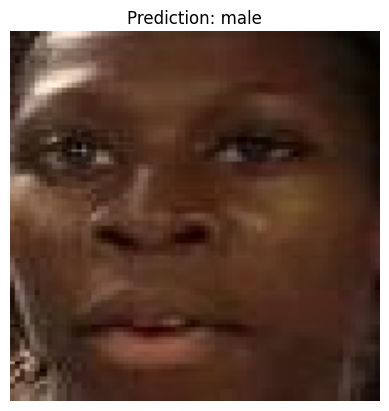

In [3]:
import os
import shutil
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

# ==============================================================================
# 1. Image Conversion & Cleanup
# ==============================================================================
# Ensure your starting dataset at '/content/Dataset' contains 'male' and 'female' folders
source_dir = '/content/Dataset'
target_dir = '/content/converted_dataset'

# Define the maximum number of images to copy per class
MAX_IMAGES_PER_CLASS = 1000 # You can adjust this number

if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

os.makedirs(target_dir, exist_ok=True)
print(f"Converting/Copying images from '{source_dir}' to '{target_dir}' (max {MAX_IMAGES_PER_CLASS} per class)...")

# Convert and copy images to converted_dataset
for class_name in os.listdir(source_dir):
    class_source_path = os.path.join(source_dir, class_name)
    class_target_path = os.path.join(target_dir, class_name)

    if os.path.isdir(class_source_path):
        os.makedirs(class_target_path, exist_ok=True)

        images_copied = 0
        for image_name in os.listdir(class_source_path):
            if images_copied >= MAX_IMAGES_PER_CLASS:
                break # Stop copying once the limit is reached for this class

            image_source_path = os.path.join(class_source_path, image_name)

            # Determine the new filename with a .jpeg extension
            # Handles 'image.jpg.jpg' to 'image.jpeg' and 'image.png' to 'image.jpeg'
            if image_name.lower().endswith('.jpg.jpg'):
                base_name = image_name[:-8] # remove '.jpg.jpg'
                new_image_name = base_name + '.jpeg'
            else:
                # For other image types, get base name and append .jpeg
                base_name = os.path.splitext(image_name)[0]
                new_image_name = base_name + '.jpeg'

            image_target_path = os.path.join(class_target_path, new_image_name)

            try:
                with Image.open(image_source_path) as img:
                    img.convert('RGB').save(image_target_path, 'jpeg')
                images_copied += 1
            except Exception as e:
                print(f"Error processing {image_source_path}: {e}")

print(f"All images processed and saved as .jpeg to the new directory (up to {MAX_IMAGES_PER_CLASS} per class).")

# Remove checkpoint folder to prevent ValueError during num_classes=2 training
checkpoint_folder_converted = os.path.join(target_dir, '.ipynb_checkpoints')
if os.path.exists(checkpoint_folder_converted):
    shutil.rmtree(checkpoint_folder_converted)
    print(f"Deleted unexpected '.ipynb_checkpoints' folder from '{target_dir}'")

# ==============================================================================
# 2. Model Initialization and Training
# ==============================================================================
train_data_dir = target_dir
validation_data_dir = target_dir

img_width, img_height = 150, 150
batch_size = 32
epochs = 10
num_classes = 2  # Set to 2 for binary classification

def create_model():
    model = models.Sequential([
        tf.keras.Input(shape=(img_width, img_height, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Normalize pixel values between 0 and 1 and apply augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary'
)

print('Train Generator Class Indices:', train_generator.class_indices)
print('Validation Generator Class Indices:', validation_generator.class_indices)

model = create_model()

model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

model.save('binary_image_classifier.keras')
print("Training and validation completed!")

# ==============================================================================
# 3. Inference and Visualization
# ==============================================================================

# Point this to an existing image in your dataset for testing
# img_path = '/content/converted_dataset/male/sample-image.jpeg' # Original line

# Find an actual image to use for inference
# Let's try to get one from the 'male' class for demonstration
img_path = None
male_dir = os.path.join(target_dir, 'male')
if os.path.exists(male_dir):
    male_images = [f for f in os.listdir(male_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if male_images:
        img_path = os.path.join(male_dir, male_images[0]) # Take the first image found

if img_path and os.path.exists(img_path):
    img = image.load_img(img_path, target_size=(150, 150))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x /= 255.0  # Normalize pixel values between 0 and 1

    predictions = model.predict(x)
    pred = predictions[0][0]

    # Threshold maps to the class_indices assigned by flow_from_directory
    # Alphabetically, "female" -> 0, "male" -> 1
    if pred >= 0.5:
        result = "male"
    else:
        result = "female"

    plt.imshow(img)
    plt.title(f"Prediction: {result}")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not find an image for inference in {male_dir}. Please ensure images are available.")